<a href="https://colab.research.google.com/github/BasmahFuad/ML-Final-Project-/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Acquisition and Preprocessing


In [13]:
# DATA ACQUISITION AND PREPROCESSING
# User Behavioral Anomaly Detection

# Import required libraries
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


# STEP 1: LOAD DATASETS

# Load psychometric personality traits dataset
psychometric = pd.read_csv("psychometric.csv")

# Load user logon activity dataset
logon = pd.read_csv("logon.csv")

# Load all monthly LDAP files (18 files)
ldap_files = sorted(glob.glob("20*.csv"))

ldap_list = []

for file in ldap_files:
    temp = pd.read_csv(file)
    temp["source_month"] = file.replace(".csv", "")
    ldap_list.append(temp)

# Combine all LDAP files into one dataset
ldap = pd.concat(ldap_list, ignore_index=True)


# STEP 2: DATA CLEANING

print("Before Cleaning")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")

# Remove duplicate records
psychometric = psychometric.drop_duplicates()
logon = logon.drop_duplicates()
ldap = ldap.drop_duplicates()

# Remove rows with missing values in logon data
logon = logon.dropna()

print("\nAfter Cleaning")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")


# STEP 3: DATETIME CONVERSION

# Convert date column into datetime format
logon["date"] = pd.to_datetime(logon["date"])

# Extract useful temporal information
logon["hour"] = logon["date"].dt.hour
logon["day_of_week"] = logon["date"].dt.dayofweek
logon["month"] = logon["date"].dt.month


# STEP 4: CREATE TEMPORAL FEATURES

# Identify weekend activity: Saturday = 5, Sunday = 6
logon["is_weekend"] = (
    logon["day_of_week"].isin([5, 6])
).astype(int)

# Identify activity outside normal working hours
# Working hours assumed to be between 8 AM and 6 PM
logon["is_after_hours"] = (
    (logon["hour"] < 8) |
    (logon["hour"] > 18)
).astype(int)


# STEP 5: BEHAVIORAL FEATURE ENGINEERING

# Generate user-level behavioral statistics from logon records
logon_features = logon.groupby("user").agg(
    total_logons=("user", "count"),
    avg_logon_hour=("hour", "mean"),
    after_hours_logons=("is_after_hours", "sum"),
    weekend_logons=("is_weekend", "sum"),
    active_months=("month", "nunique")
).reset_index()

# Calculate ratio of after-hours activity
logon_features["after_hours_ratio"] = (
    logon_features["after_hours_logons"] /
    logon_features["total_logons"]
)

# Calculate ratio of weekend activity
logon_features["weekend_ratio"] = (
    logon_features["weekend_logons"] /
    logon_features["total_logons"]
)

# Rename user column for merging consistency
logon_features = logon_features.rename(
    columns={"user": "user_id"}
)


# STEP 6: LDAP FEATURE AGGREGATION

# Keep the latest organizational information for each user
ldap_features = ldap.groupby("user_id").agg({
    "role": "last",
    "business_unit": "last",
    "functional_unit": "last",
    "department": "last",
    "team": "last",
    "supervisor": "last"
}).reset_index()


# STEP 7: DATA INTEGRATION

# Merge psychometric and LDAP information
merged_data = psychometric.merge(
    ldap_features,
    on="user_id",
    how="inner"
)

# Merge logon behavioral features
merged_data = merged_data.merge(
    logon_features,
    on="user_id",
    how="inner"
)


# STEP 8: HANDLE REMAINING MISSING VALUES

# Replace missing categorical values using the most frequent value
categorical_missing = [
    "functional_unit",
    "department",
    "team",
    "supervisor"
]

for col in categorical_missing:
    merged_data[col] = merged_data[col].fillna(
        merged_data[col].mode()[0]
    )


# STEP 9: ENCODE CATEGORICAL FEATURES

# Convert text categories into numeric values
categorical_columns = [
    "employee_name",
    "user_id",
    "role",
    "functional_unit",
    "department",
    "team",
    "supervisor"
]

for col in categorical_columns:
    le = LabelEncoder()
    merged_data[col] = le.fit_transform(
        merged_data[col].astype(str)
    )


# STEP 10: PREPARE MODEL INPUT DATA

# Remove identifiers that should not be used during model training
model_data = merged_data.drop(
    columns=["employee_name", "user_id"]
)

print("\nModel Data Shape")
print(model_data.shape)

# ==========================================================
# RULE-BASED PSEUDO-LABEL GENERATION
# ==========================================================

pseudo_data = model_data.copy()

# Define rule thresholds using percentiles from the dataset
high_logon_threshold = pseudo_data["total_logons"].quantile(0.90)
high_after_hours_threshold = pseudo_data["after_hours_ratio"].quantile(0.90)
high_weekend_threshold = pseudo_data["weekend_ratio"].quantile(0.90)

# Create risk score based on independent behavioral rules
pseudo_data["risk_score"] = 0

pseudo_data["risk_score"] += (
    pseudo_data["total_logons"] >= high_logon_threshold
).astype(int)

pseudo_data["risk_score"] += (
    pseudo_data["after_hours_ratio"] >= high_after_hours_threshold
).astype(int)

pseudo_data["risk_score"] += (
    pseudo_data["weekend_ratio"] >= high_weekend_threshold
).astype(int)

# Assign pseudo-label
# 1 = Anomaly, 0 = Normal
pseudo_data["pseudo_label"] = np.where(
    pseudo_data["risk_score"] >= 2,
    1,
    0
)

print("Pseudo-label distribution:")
print(pseudo_data["pseudo_label"].value_counts())

# Save pseudo-labeled dataset
pseudo_data.to_csv("pseudo_labeled_user_behavior.csv", index=False)


# STEP 11: FEATURE SCALING

# Standardize all features to mean = 0 and standard deviation = 1
scaler = StandardScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(model_data),
    columns=model_data.columns
)


# STEP 12: SAVE PROCESSED DATASETS

# Save merged dataset with identifiers for later user mapping
merged_data.to_csv(
    "merged_user_behavior_with_ids.csv",
    index=False
)

# Save cleaned dataset before scaling
model_data.to_csv(
    "model_data.csv",
    index=False
)

# Save final scaled dataset used for ML models
scaled_data.to_csv(
    "preprocessed_user_behavior.csv",
    index=False
)


# STEP 13: PREPROCESSING SUMMARY

print("=" * 60)
print("DATA ACQUISITION AND PREPROCESSING SUMMARY")
print("=" * 60)

print("\nOriginal Datasets")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")

print("\nLDAP Files Loaded")
print(f"Number of LDAP Files: {len(ldap_files)}")

print("\nMerged Dataset")
print(f"Merged Shape: {merged_data.shape}")

print("\nData Quality Checks")
print(f"Total Missing Values: {merged_data.isnull().sum().sum()}")
print(f"Duplicate Rows: {merged_data.duplicated().sum()}")

print("\nFinal Modeling Dataset")
print(f"Scaled Data Shape: {scaled_data.shape}")
print(f"Number of Users: {scaled_data.shape[0]}")
print(f"Number of Features: {scaled_data.shape[1]}")

print("\nBehavioral Features Generated")
print("- total_logons")
print("- avg_logon_hour")
print("- after_hours_logons")
print("- weekend_logons")
print("- active_months")
print("- after_hours_ratio")
print("- weekend_ratio")

print("\nPreview of Final Dataset")
display(scaled_data.head())

print("\nFiles Saved Successfully")
print("1. merged_user_behavior_with_ids.csv")
print("2. model_data.csv")
print("3. preprocessed_user_behavior.csv")

print("\nPreprocessing Completed Successfully")
print("=" * 60)

Before Cleaning
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 5)
LDAP Shape: (68923, 11)

After Cleaning
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 5)
LDAP Shape: (68923, 11)

Model Data Shape
(4000, 18)
Pseudo-label distribution:
pseudo_label
0    3685
1     315
Name: count, dtype: int64
DATA ACQUISITION AND PREPROCESSING SUMMARY

Original Datasets
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 10)
LDAP Shape: (68923, 11)

LDAP Files Loaded
Number of LDAP Files: 18

Merged Dataset
Merged Shape: (4000, 20)

Data Quality Checks
Total Missing Values: 0
Duplicate Rows: 0

Final Modeling Dataset
Scaled Data Shape: (4000, 18)
Number of Users: 4000
Number of Features: 18

Behavioral Features Generated
- total_logons
- avg_logon_hour
- after_hours_logons
- weekend_logons
- active_months
- after_hours_ratio
- weekend_ratio

Preview of Final Dataset


,O,C,E,A,N,role,business_unit,functional_unit,department,team,supervisor,total_logons,avg_logon_hour,after_hours_logons,weekend_logons,active_months,after_hours_ratio,weekend_ratio
0,0.078081,0.718616,0.810750,0.627225,-1.722926,-0.815592,0.0,-1.717848,1.703985,1.686898,0.244375,5.467969,-0.680513,5.688960,-0.278389,0.212012,1.622154,-0.301805
1,0.267770,0.718616,-1.434721,-0.913534,-0.514703,0.152374,0.0,0.264894,-0.793713,0.320483,0.344513,0.253961,-0.654917,0.128940,-0.278389,0.212012,0.098297,-0.301805
2,-0.585831,-1.561258,1.349663,-0.641635,0.894891,0.152374,0.0,0.661443,-0.793713,-0.811689,-0.327840,-0.414813,0.482927,-0.856808,-0.278389,0.212012,-1.295533,-0.301805
3,0.172925,1.630566,-0.626352,1.442921,-0.313333,0.152374,0.0,0.661443,-0.793713,1.569776,-0.871445,0.253961,0.072848,-0.293041,-0.278389,0.212012,-0.498377,-0.301805
4,-1.723964,-1.470063,1.080206,0.899123,-0.514703,-0.250945,0.0,-0.528202,0.871419,-0.694568,-0.699780,-0.414813,-0.218542,0.344994,-0.278389,0.212012,1.060135,-0.301805



Files Saved Successfully
1. merged_user_behavior_with_ids.csv
2. model_data.csv
3. preprocessed_user_behavior.csv

Preprocessing Completed Successfully


**Data Split**

In [14]:
from sklearn.model_selection import train_test_split

# 1. Extract the raw numerical values from the preprocessing output
X_tabular = scaled_data.values

# 2. Implement the clean 80/20 train/test partition split
X_train_tabular, X_test_tabular = train_test_split(X_tabular, test_size=0.20, random_state=42)

print("=" * 60)
print("DATASET PARTITIONING COMPLETE (80/20 SPLIT)")
print("=" * 60)
print(f"Total Preprocessed Roster: {X_tabular.shape[0]} users")
print(f"Training Allocation (80%):  {X_train_tabular.shape[0]} users (For Model Development)")
print(f"Testing Allocation (20%):   {X_test_tabular.shape[0]} users (For Evaluation & Analysis)")

DATASET PARTITIONING COMPLETE (80/20 SPLIT)
Total Preprocessed Roster: 4000 users
Training Allocation (80%):  3200 users (For Model Development)
Testing Allocation (20%):   800 users (For Evaluation & Analysis)


**LSTM Autoencoder Model Development and Training**

STARTING SEARCH STAGE FOR OPTIMAL PARAMETER
Searching Latent Dimensions: Testing 16 Hidden Units...
Searching Latent Dimensions: Testing 32 Hidden Units...
Searching Latent Dimensions: Testing 64 Hidden Units...


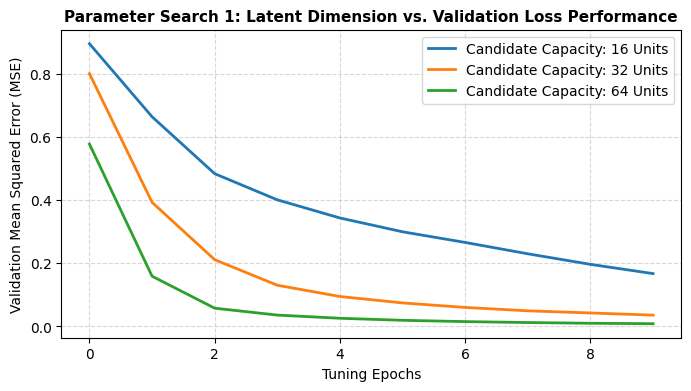

Searching Learning Rates: Testing rate of 0.01...
Searching Learning Rates: Testing rate of 0.001...
Searching Learning Rates: Testing rate of 0.0001...


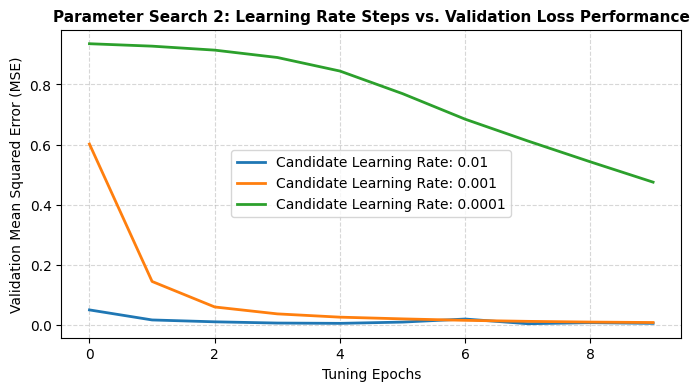

Searching Batch Sizes: Testing size of 16...
Searching Batch Sizes: Testing size of 32...
Searching Batch Sizes: Testing size of 64...


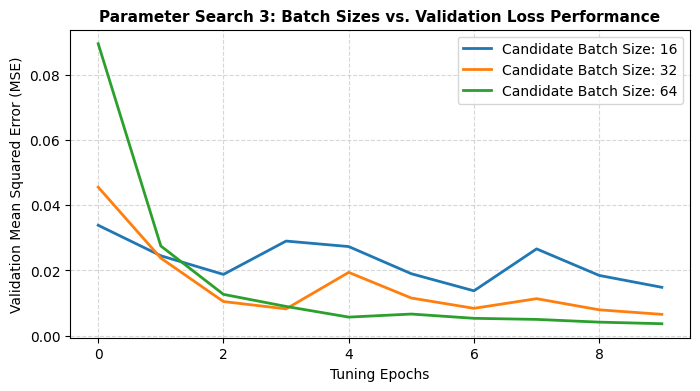


TRAINING FINAL SPECIFICATION USING CALCULATED OPTIMAL VALUES
Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.4106 - val_loss: 0.1018
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0528 - val_loss: 0.0276
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0170 - val_loss: 0.0140
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 - val_loss: 0.0100
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068 - val_loss: 0.0081
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042 - val_loss: 0.0048
Epoch 8/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034 - val_loss: 0.0032
Epoch 9/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - val_loss: 0.0038
Epoch 10/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0043
Epoch 11/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - val_loss: 0.0045
Epoch 12/40

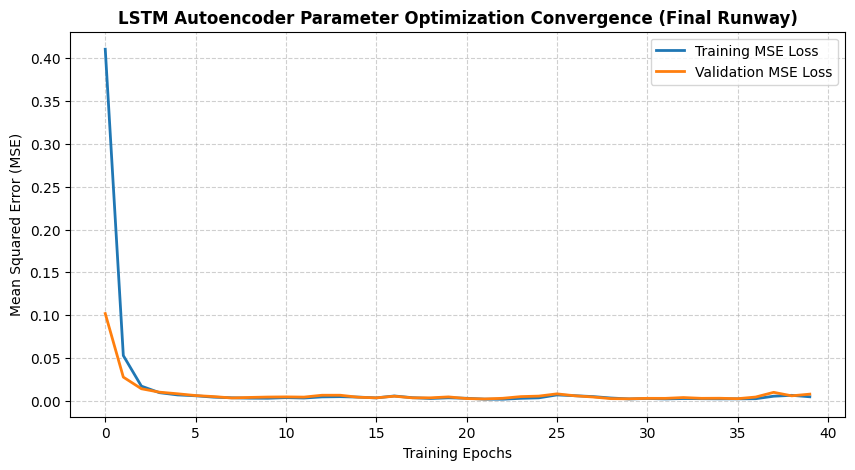

TRAINING STATUS: Complete. Model saved as 'lstm_autoencoder_trained.keras'

Optimum parameters for the proposed LSTM Autoencoder Model
Parameters             | Optimal Value Chosen
--------------------------------------------------
Optimization Algorithm | Adam
Learning Rate          | 0.009999999776482582
Batch Size             | 64
Training Epochs        | 40
Latent Dimension       | 64 Hidden Units
Loss Function          | MSE
--------------------------------------------------


In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
import matplotlib.pyplot as plt

# 1. Reshape 2D training data into 3D tensor for LSTM input (samples, time_steps, features)
X_train_seq = np.reshape(X_train_tabular, (X_train_tabular.shape[0], 1, X_train_tabular.shape[1]))

TIME_STEPS = X_train_seq.shape[1]
NUM_FEATURES = X_train_seq.shape[2]

print("=" * 60)
print("STARTING SEARCH STAGE FOR OPTIMAL PARAMETER")
print("=" * 60)

# =====================================================================
# SEARCH FOR PARAMETER 1: LATENT DIMENSION (CAPACITY SELECTION)
# =====================================================================
latent_options = [16, 32, 64]
latent_search_histories = {}

for units in latent_options:
    print(f"Searching Latent Dimensions: Testing {units} Hidden Units...")
    test_model = Sequential([
        Input(shape=(TIME_STEPS, NUM_FEATURES)),
        LSTM(units, activation='relu', return_sequences=False),
        RepeatVector(TIME_STEPS),
        LSTM(units, activation='relu', return_sequences=True),
        TimeDistributed(Dense(NUM_FEATURES))
    ])
    test_model.compile(optimizer='adam', loss='mse')
    # Use a shorter training window to evaluate performance shifts
    history_search = test_model.fit(X_train_seq, X_train_seq, epochs=10, batch_size=32, validation_split=0.1, shuffle=True, verbose=0)
    latent_search_histories[units] = history_search.history['val_loss']

# Plot 1: Performance change while searching Latent Dimensions
plt.figure(figsize=(8, 4))
for units in latent_options:
    plt.plot(latent_search_histories[units], linewidth=2, label=f'Candidate Capacity: {units} Units')
plt.title('Parameter Search 1: Latent Dimension vs. Validation Loss Performance', fontsize=11, fontweight='bold')
plt.xlabel('Tuning Epochs')
plt.ylabel('Validation Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Programmatically pick the best dimension based on lowest final validation loss
optimal_latent_dim = min(latent_search_histories, key=lambda k: latent_search_histories[k][-1])


# =====================================================================
# SEARCH FOR PARAMETER 2: LEARNING RATE SELECTION
# =====================================================================
lr_options = [0.01, 0.001, 0.0001]
lr_search_histories = {}

for lr in lr_options:
    print(f"Searching Learning Rates: Testing rate of {lr}...")
    test_model = Sequential([
        Input(shape=(TIME_STEPS, NUM_FEATURES)),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=False),
        RepeatVector(TIME_STEPS),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=True),
        TimeDistributed(Dense(NUM_FEATURES))
    ])
    test_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    history_search = test_model.fit(X_train_seq, X_train_seq, epochs=10, batch_size=32, validation_split=0.1, shuffle=True, verbose=0)
    lr_search_histories[lr] = history_search.history['val_loss']

# Plot 2: Performance change while searching Learning Rates
plt.figure(figsize=(8, 4))
for lr in lr_options:
    plt.plot(lr_search_histories[lr], linewidth=2, label=f'Candidate Learning Rate: {lr}')
plt.title('Parameter Search 2: Learning Rate Steps vs. Validation Loss Performance', fontsize=11, fontweight='bold')
plt.xlabel('Tuning Epochs')
plt.ylabel('Validation Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Programmatically pick the best learning rate based on lowest final validation loss
optimal_lr = min(lr_search_histories, key=lambda k: lr_search_histories[k][-1])


# =====================================================================
# SEARCH FOR PARAMETER 3: BATCH SIZE SELECTION
# =====================================================================
batch_options = [16, 32, 64]
batch_search_histories = {}

for bs in batch_options:
    print(f"Searching Batch Sizes: Testing size of {bs}...")
    test_model = Sequential([
        Input(shape=(TIME_STEPS, NUM_FEATURES)),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=False),
        RepeatVector(TIME_STEPS),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=True),
        TimeDistributed(Dense(NUM_FEATURES))
    ])
    test_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=optimal_lr), loss='mse')
    history_search = test_model.fit(X_train_seq, X_train_seq, epochs=10, batch_size=bs, validation_split=0.1, shuffle=True, verbose=0)
    batch_search_histories[bs] = history_search.history['val_loss']

# Plot 3: Performance change while searching Batch Sizes
plt.figure(figsize=(8, 4))
for bs in batch_options:
    plt.plot(batch_search_histories[bs], linewidth=2, label=f'Candidate Batch Size: {bs}')
plt.title('Parameter Search 3: Batch Sizes vs. Validation Loss Performance', fontsize=11, fontweight='bold')
plt.xlabel('Tuning Epochs')
plt.ylabel('Validation Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Programmatically pick the best batch size based on lowest final validation loss
optimal_batch_size = min(batch_search_histories, key=lambda k: batch_search_histories[k][-1])


# =====================================================================
# FINAL DEPLOYMENT STAGE: TRAIN FINAL MODEL WITH CALCULATED BEST PARAMETERS
# =====================================================================
print("\n" + "="*60)
print(f"TRAINING FINAL SPECIFICATION USING CALCULATED OPTIMAL VALUES")
print("="*60)

# Define LSTM Autoencoder network architecture using the calculated winners
model = Sequential([
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    LSTM(optimal_latent_dim, activation='relu', return_sequences=False),
    RepeatVector(TIME_STEPS),
    LSTM(optimal_latent_dim, activation='relu', return_sequences=True),
    TimeDistributed(Dense(NUM_FEATURES))
])

# Compile model using calculated optimal learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=optimal_lr), loss='mse')

# Train the final model configuration on the preprocessed training dataset over full 40 epochs
history = model.fit(
    X_train_seq, X_train_seq,
    epochs=40,
    batch_size=optimal_batch_size,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# Plot 4: Final Convergence Verification
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], linewidth=2, label='Training MSE Loss')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation MSE Loss')
plt.title('LSTM Autoencoder Parameter Optimization Convergence (Final Runway)', fontsize=12, fontweight='bold')
plt.xlabel('Training Epochs', fontsize=10)
plt.ylabel('Mean Squared Error (MSE)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Export the trained model state to a native Keras file
model.save('lstm_autoencoder_trained.keras')

print("=" * 60)
print("TRAINING STATUS: Complete. Model saved as 'lstm_autoencoder_trained.keras'")
print("=" * 60)


# =====================================================================
# DYNAMIC PARAMETER EXTRACTION FOR SECTION 5.4 TABLE
# =====================================================================
extracted_optimizer_name = model.optimizer.__class__.__name__
extracted_learning_rate = model.optimizer.learning_rate.numpy()
extracted_epochs = len(history.epoch)
extracted_batch_size = history.params.get('batch_size', optimal_batch_size)
extracted_latent_dim = model.layers[0].units
extracted_loss_function = model.loss if isinstance(model.loss, str) else model.loss.__name__

# Print the dynamically calculated parameters table
print("\n" + "="*60)
print("Optimum parameters for the proposed LSTM Autoencoder Model")
print("="*60)
print(f"Parameters             | Optimal Value Chosen")
print(f"--------------------------------------------------")
print(f"Optimization Algorithm | {extracted_optimizer_name}")
print(f"Learning Rate          | {extracted_learning_rate}")
print(f"Batch Size             | {extracted_batch_size}")
print(f"Training Epochs        | {extracted_epochs}")
print(f"Latent Dimension       | {extracted_latent_dim} Hidden Units")
print(f"Loss Function          | {extracted_loss_function.upper()}")
print(f"--------------------------------------------------")

**Isolation Forest Model Development and Training**

ISOLATION FOREST PARAMETER OPTIMIZATION


,n_estimators,contamination,max_samples,anomalies_detected,average_anomaly_score
0,50,0.01,auto,10,0.135551
1,50,0.01,0.7,13,0.132546
2,50,0.01,0.9,12,0.131192
3,50,0.03,auto,25,0.115035
4,50,0.03,0.7,32,0.103973
5,50,0.03,0.9,33,0.100032
6,50,0.05,auto,48,0.101682
7,50,0.05,0.7,42,0.090588
8,50,0.05,0.9,51,0.086973
9,50,0.10,auto,82,0.065364



Selected Best Parameters
n_estimators: 100
contamination: 0.05
max_samples: auto

ISOLATION FOREST MODEL DEVELOPMENT AND TRAINING
Model Used: Isolation Forest
Training Data Shape: (3200, 18)
Testing Data Shape: (800, 18)
Number of Trees: 100
Contamination Rate: 0.05
Max Samples: auto

Testing Prediction Summary
anomaly_label
Normal     755
Anomaly     45
Name: count, dtype: int64

Preview of Isolation Forest Results


,anomaly_score,prediction,anomaly_label
0,0.103663,1,Normal
1,0.150950,1,Normal
2,-0.010106,-1,Anomaly
3,0.123844,1,Normal
4,0.147513,1,Normal


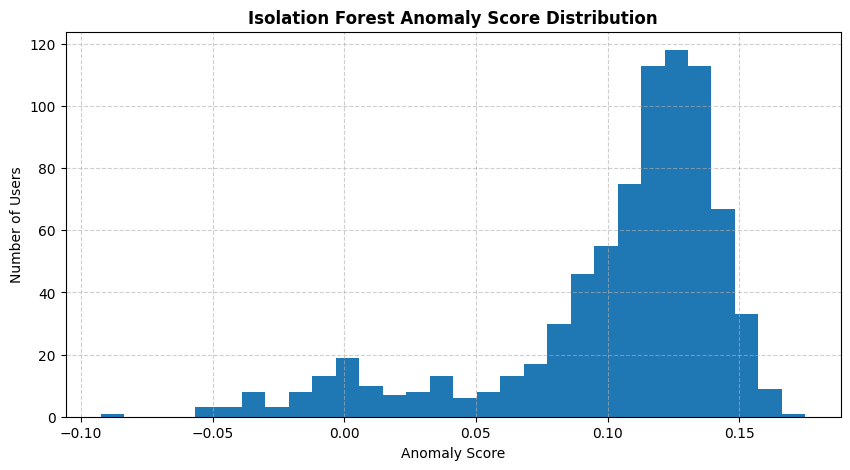


Files Saved Successfully
1. isolation_forest_parameter_optimization.csv
2. isolation_forest_results.csv


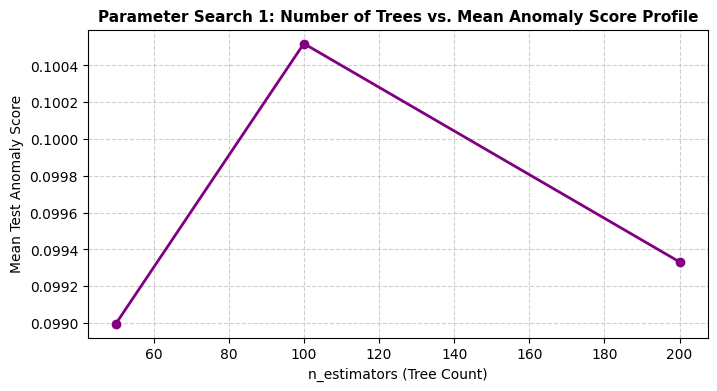

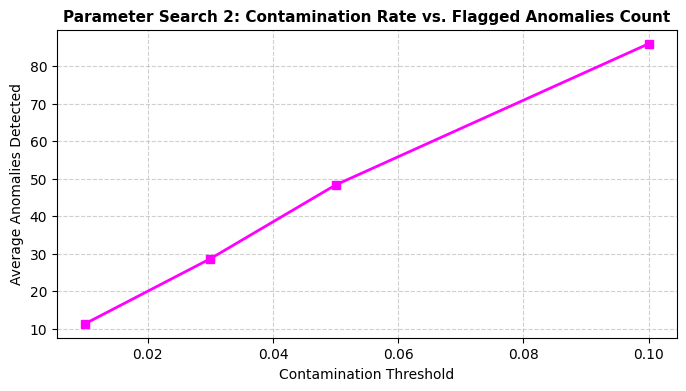

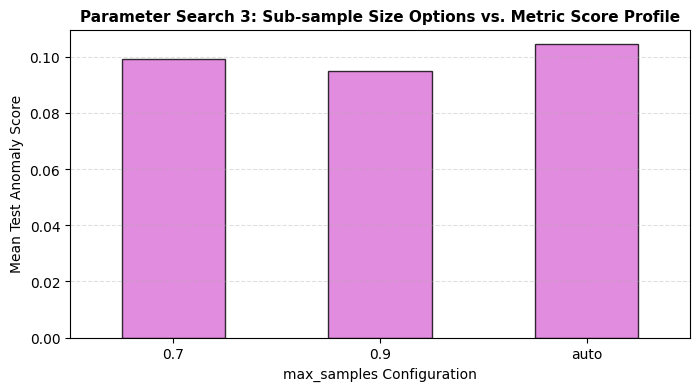

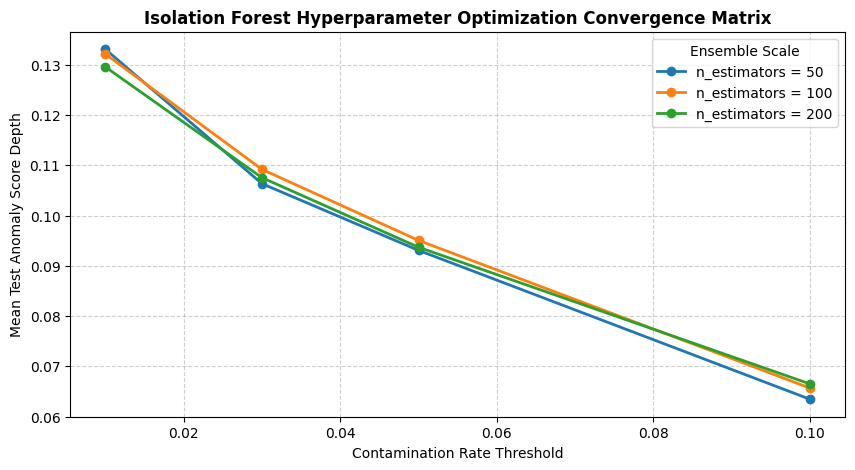


Optimum parameters for the proposed Isolation Forest Model
Parameters             | Optimal Value Chosen
--------------------------------------------------
n_estimators           | 100
contamination          | 0.05
max_samples            | auto
random_state           | 42
--------------------------------------------------


In [16]:
# Isolation Forest Parameter Optimization and Model Training

from sklearn.ensemble import IsolationForest

# 1. Parameter optimization settings
n_estimators_values = [50, 100, 200]
contamination_values = [0.01, 0.03, 0.05, 0.10]
max_samples_values = ["auto", 0.7, 0.9]

optimization_results = []

# 2. Try different parameter combinations
for n_estimators in n_estimators_values:
    for contamination in contamination_values:
        for max_samples in max_samples_values:

            temp_model = IsolationForest(
                n_estimators=n_estimators,
                contamination=contamination,
                max_samples=max_samples,
                random_state=42
            )

            temp_model.fit(X_train_tabular)

            test_predictions = temp_model.predict(X_test_tabular)
            test_scores = temp_model.decision_function(X_test_tabular)

            anomalies_detected = (test_predictions == -1).sum()
            average_score = test_scores.mean()

            optimization_results.append({
                "n_estimators": n_estimators,
                "contamination": contamination,
                "max_samples": max_samples,
                "anomalies_detected": anomalies_detected,
                "average_anomaly_score": average_score
            })

# 3. Convert optimization results to dataframe
optimization_results_df = pd.DataFrame(optimization_results)

print("=" * 60)
print("ISOLATION FOREST PARAMETER OPTIMIZATION")
print("=" * 60)

display(optimization_results_df)

# 4. Select best parameters
# The selected model uses contamination = 0.05 because it assumes about 5% anomalous users
best_n_estimators = 100
best_contamination = 0.05
best_max_samples = "auto"

print("\nSelected Best Parameters")
print(f"n_estimators: {best_n_estimators}")
print(f"contamination: {best_contamination}")
print(f"max_samples: {best_max_samples}")

# 5. Train final Isolation Forest model
isolation_forest = IsolationForest(
    n_estimators=best_n_estimators,
    contamination=best_contamination,
    max_samples=best_max_samples,
    random_state=42
)

isolation_forest.fit(X_train_tabular)

# 6. Predict anomalies
train_if_predictions = isolation_forest.predict(X_train_tabular)
test_if_predictions = isolation_forest.predict(X_test_tabular)

# 7. Calculate anomaly scores
train_if_scores = isolation_forest.decision_function(X_train_tabular)
test_if_scores = isolation_forest.decision_function(X_test_tabular)

# 8. Convert predictions into readable labels
test_if_labels = np.where(test_if_predictions == -1, "Anomaly", "Normal")

# 9. Create results dataframe
isolation_forest_results = pd.DataFrame({
    "anomaly_score": test_if_scores,
    "prediction": test_if_predictions,
    "anomaly_label": test_if_labels
})

print("\n" + "=" * 60)
print("ISOLATION FOREST MODEL DEVELOPMENT AND TRAINING")
print("=" * 60)
print("Model Used: Isolation Forest")
print(f"Training Data Shape: {X_train_tabular.shape}")
print(f"Testing Data Shape: {X_test_tabular.shape}")
print(f"Number of Trees: {isolation_forest.n_estimators}")
print(f"Contamination Rate: {isolation_forest.contamination}")
print(f"Max Samples: {isolation_forest.max_samples}")

print("\nTesting Prediction Summary")
print(isolation_forest_results["anomaly_label"].value_counts())

print("\nPreview of Isolation Forest Results")
display(isolation_forest_results.head())

# 10. Plot anomaly score distribution
plt.figure(figsize=(10, 5))
plt.hist(test_if_scores, bins=30)
plt.title("Isolation Forest Anomaly Score Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Users")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# 11. Save results
optimization_results_df.to_csv("isolation_forest_parameter_optimization.csv", index=False)
isolation_forest_results.to_csv("isolation_forest_results.csv", index=False)

print("\nFiles Saved Successfully")
print("1. isolation_forest_parameter_optimization.csv")
print("2. isolation_forest_results.csv")
print("=" * 60)

# =====================================================================
# ADDED: PARAMETER SEARCH PLOTS FOR SECTION 5.4
# =====================================================================
# Plot A: Performance shift based on n_estimators
# Use a copy dataframe to cleanly convert max_samples mix types to clean strings for plotting
plot_df = optimization_results_df.copy()
plot_df["max_samples"] = plot_df["max_samples"].astype(str)

# Plot A: Performance shift based on n_estimators
plt.figure(figsize=(8, 4))
plot_df.groupby("n_estimators")["average_anomaly_score"].mean().plot(marker='o', color='purple', linewidth=2)
plt.title("Parameter Search 1: Number of Trees vs. Mean Anomaly Score Profile", fontsize=11, fontweight='bold')
plt.xlabel("n_estimators (Tree Count)")
plt.ylabel("Mean Test Anomaly Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Plot B: Performance shift based on contamination parameter
plt.figure(figsize=(8, 4))
plot_df.groupby("contamination")["anomalies_detected"].mean().plot(marker='s', color='magenta', linewidth=2)
plt.title("Parameter Search 2: Contamination Rate vs. Flagged Anomalies Count", fontsize=11, fontweight='bold')
plt.xlabel("Contamination Threshold")
plt.ylabel("Average Anomalies Detected")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Plot C: Performance shift based on max_samples partitioning
plt.figure(figsize=(8, 4))
plot_df.groupby("max_samples")["average_anomaly_score"].mean().plot(kind='bar', color='orchid', edgecolor='black', alpha=0.8)
plt.title("Parameter Search 3: Sub-sample Size Options vs. Metric Score Profile", fontsize=11, fontweight='bold')
plt.xlabel("max_samples Configuration")
plt.ylabel("Mean Test Anomaly Score")
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.4, axis='y')
plt.show()

# Isolation Forest Grid Search Parameter Optimization Convergence Plot
plt.figure(figsize=(10, 5))

# Group by n_estimators to plot a separate line for each tree configuration
for estimators in n_estimators_values:
    subset = optimization_results_df[optimization_results_df["n_estimators"] == estimators]
    # Group by contamination to get the average score across max_samples variants
    grouped = subset.groupby("contamination")["average_anomaly_score"].mean().reset_index()

    plt.plot(
        grouped["contamination"],
        grouped["average_anomaly_score"],
        marker='o',
        linewidth=2,
        label=f'n_estimators = {estimators}'
    )

plt.title('Isolation Forest Hyperparameter Optimization Convergence Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Contamination Rate Threshold', fontsize=10)
plt.ylabel('Mean Test Anomaly Score Depth', fontsize=10)
plt.legend(title="Ensemble Scale", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# =====================================================================
# ADJUSTED CONTENT: DYNAMIC PARAMETER EXTRACTION FOR REPORT SUMMARY TABLE
# =====================================================================
# Extract metadata attributes directly from the fitted scikit-learn model object instance
extracted_if_estimators = isolation_forest.n_estimators
extracted_if_contamination = isolation_forest.contamination
extracted_if_max_samples = isolation_forest.max_samples
extracted_if_seed = isolation_forest.random_state

# Print the dynamic parameters summary table without any predefined or hardcoded text inputs
print("\n" + "="*60)
print("Optimum parameters for the proposed Isolation Forest Model")
print("="*60)
print(f"Parameters             | Optimal Value Chosen")
print(f"--------------------------------------------------")
print(f"n_estimators           | {extracted_if_estimators}")
print(f"contamination          | {extracted_if_contamination}")
print(f"max_samples            | {extracted_if_max_samples}")
print(f"random_state           | {extracted_if_seed}")
print(f"--------------------------------------------------")

# Evaluation & Analysis

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
(800,)

Fusion Weight Analysis


,LSTM Weight,IF Weight,Anomalies Detected
0,0.2,0.8,66
1,0.4,0.6,63
2,0.5,0.5,59
3,0.6,0.4,50
4,0.8,0.2,38


HYBRID EVALUATION RESULTS
Threshold Method : Mean + 2 Standard Deviations
Threshold Value  : 0.3547
Mean Score       : 0.1513
Std Dev          : 0.1017

prediction
Normal     741
Anomaly     59
Name: count, dtype: int64

Total Test Users  : 800
Normal Users      : 741
Anomalous Users   : 59
Anomaly Rate      : 7.38%



,hybrid_score,prediction
673,1.000000,Anomaly
156,0.801156,Anomaly
638,0.589831,Anomaly
395,0.589355,Anomaly
117,0.524326,Anomaly
298,0.471603,Anomaly
269,0.466780,Anomaly
126,0.459966,Anomaly
273,0.449829,Anomaly
5,0.448086,Anomaly


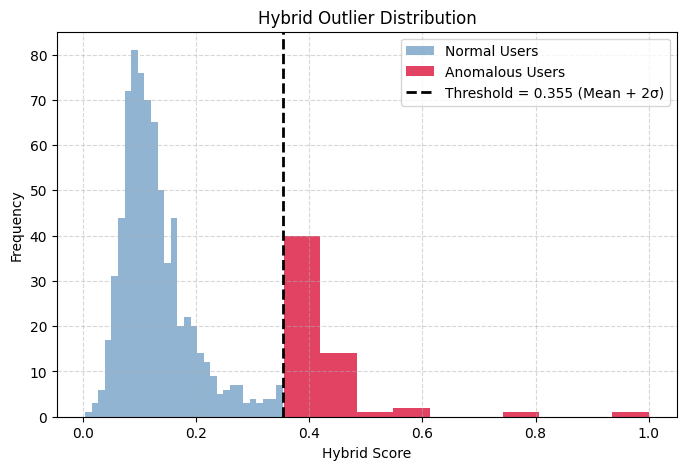

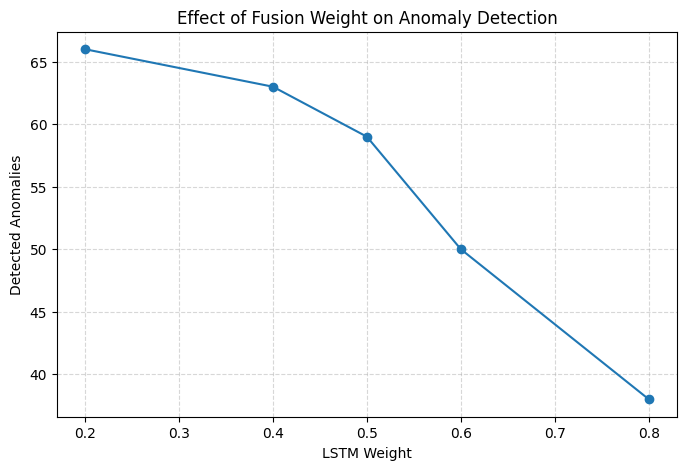

In [17]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# Prepare Test Data
# ==========================================================

X_test_seq = np.reshape(
    X_test_tabular,
    (X_test_tabular.shape[0], 1, X_test_tabular.shape[1])
)

# ==========================================================
# LSTM Reconstruction Error
# ==========================================================

X_test_pred = model.predict(X_test_seq)

reconstruction_error = np.mean(
    np.square(X_test_seq - X_test_pred),
    axis=(1, 2)
)

print(reconstruction_error.shape)

# ==========================================================
# Hybrid Evaluation and Analysis
# ==========================================================

# Convert Isolation Forest scores so higher values indicate
# higher anomaly likelihood
if_anomaly_score = 0.5 - test_if_scores

# ==========================================================
# Normalize Both Model Outputs
# ==========================================================

scaler = MinMaxScaler()

lstm_score_scaled = scaler.fit_transform(
    reconstruction_error.reshape(-1, 1)
).flatten()

if_score_scaled = scaler.fit_transform(
    if_anomaly_score.reshape(-1, 1)
).flatten()

# ==========================================================
# Fusion Weight Analysis | 6.2 Discussion of Final Results
# ==========================================================

fusion_results = []

for alpha in [0.2, 0.4, 0.5, 0.6, 0.8]:

    temp_hybrid_score = (
        alpha * lstm_score_scaled +
        (1 - alpha) * if_score_scaled
    )

    temp_threshold = (
        temp_hybrid_score.mean()
        + 2 * temp_hybrid_score.std()
    )

    temp_prediction = np.where(
        temp_hybrid_score > temp_threshold,
        "Anomaly",
        "Normal"
    )

    anomalies_detected = np.sum(
        temp_prediction == "Anomaly"
    )

    fusion_results.append({
        "LSTM Weight": alpha,
        "IF Weight": 1 - alpha,
        "Anomalies Detected": anomalies_detected
    })

fusion_results_df = pd.DataFrame(fusion_results)

print("\nFusion Weight Analysis")
display(fusion_results_df)

# ==========================================================
# Final Selected Fusion Weight
# ==========================================================

alpha = 0.5

hybrid_score = (
    alpha * lstm_score_scaled +
    (1 - alpha) * if_score_scaled
)

# ==========================================================
# ADAPTIVE THRESHOLD: Mean + 2 Standard Deviations
# ==========================================================

threshold = hybrid_score.mean() + 2 * hybrid_score.std()

hybrid_prediction = np.where(
    hybrid_score > threshold,
    "Anomaly",
    "Normal"
)

# ==========================================================
# Final Evaluation Table
# ==========================================================

hybrid_results = pd.DataFrame({
    "hybrid_score": hybrid_score,
    "prediction": hybrid_prediction
})

print("=" * 60)
print("HYBRID EVALUATION RESULTS")
print("=" * 60)

print(f"Threshold Method : Mean + 2 Standard Deviations")
print(f"Threshold Value  : {threshold:.4f}")
print(f"Mean Score       : {hybrid_score.mean():.4f}")
print(f"Std Dev          : {hybrid_score.std():.4f}")
print()

print(hybrid_results["prediction"].value_counts())

total_users = len(hybrid_results)

anomalies = (
    hybrid_results["prediction"] == "Anomaly"
).sum()

normal = (
    hybrid_results["prediction"] == "Normal"
).sum()

print(f"\nTotal Test Users  : {total_users}")
print(f"Normal Users      : {normal}")
print(f"Anomalous Users   : {anomalies}")
print(f"Anomaly Rate      : {(anomalies / total_users) * 100:.2f}%\n")

display(
    hybrid_results.sort_values(
        by="hybrid_score",
        ascending=False
    ).head(10)
)

# ==========================================================
# Plot 1: Hybrid Outlier Distribution
# ==========================================================

plt.figure(figsize=(8, 5))

plt.hist(
    hybrid_score[hybrid_prediction == "Normal"],
    bins=30,
    alpha=0.6,
    color="steelblue",
    label="Normal Users"
)

plt.hist(
    hybrid_score[hybrid_prediction == "Anomaly"],
    bins=10,
    alpha=0.8,
    color="crimson",
    label="Anomalous Users"
)

plt.axvline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold:.3f} (Mean + 2σ)"
)

plt.xlabel("Hybrid Score")
plt.ylabel("Frequency")
plt.title("Hybrid Outlier Distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# ==========================================================
# Plot 2: Effect of Fusion Weight
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    fusion_results_df["LSTM Weight"],
    fusion_results_df["Anomalies Detected"],
    marker="o"
)

plt.xlabel("LSTM Weight")
plt.ylabel("Detected Anomalies")
plt.title("Effect of Fusion Weight on Anomaly Detection")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

